# Food & Restaurant AI Demand Forecasting and Inventory Optimization 
# Week 1 Time-Series EDA

## Objective
This notebook focuses on:
- Data ingestion and cleaning
- Creating a continuous time-series
- Performing time-series specific EDA
- Identifying trends, seasonality, and patterns
- Understanding temporal dependencies using ACF/PACF
- Generating business insights

---

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

## 1) Load Data

In [55]:
df = pd.read_csv('../data/raw/balaji_fast_food_sales_dataset.csv')
df.head()

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale,day_of_week,hour,customer_type,order_channel,preparation_time_minutes,item_popularity,profit_percent
0,1,01-04-2024,Aalopuri,Fastfood,20.0,13,260.0,Card,Mr.,Night,Monday,00:54,New,Takeaway,19,Normal Demand,9
1,2,01-04-2024,Vadapav,Fastfood,20.0,15,300.0,Cash,Mr.,Afternoon,Monday,17:44,Returning,Dine-In,22,Normal Demand,78
2,3,01-04-2024,Vadapav,Fastfood,20.0,1,20.0,Cash,Mr.,Afternoon,Monday,05:12,Regular,Dine-In,16,Normal Demand,66
3,4,01-04-2024,Sugarcane juice,Beverages,25.0,6,150.0,Online,Mr.,Night,Thursday,17:59,Returning,Dine-In,13,High Demand,44
4,5,01-04-2024,Sugarcane juice,Beverages,25.0,8,200.0,Online,Mr.,Evening,Thursday,13:59,New,Dine-In,5,High Demand,44


## 2) Basic Inspection

In [56]:
print("Shape:", df.shape)
df.info()
df.describe(include="all").T


Shape: (20000, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   order_id                  20000 non-null  int64  
 1   date                      20000 non-null  object 
 2   item_name                 20000 non-null  object 
 3   item_type                 20000 non-null  object 
 4   item_price                20000 non-null  float64
 5   quantity                  20000 non-null  int64  
 6   transaction_amount        20000 non-null  float64
 7   transaction_type          20000 non-null  object 
 8   received_by               20000 non-null  object 
 9   time_of_sale              20000 non-null  object 
 10  day_of_week               20000 non-null  object 
 11  hour                      20000 non-null  object 
 12  customer_type             20000 non-null  object 
 13  order_channel             20000 non-null  

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,20000.0,NaN,NaN,NaN,10000.5,5773.647028,1.0,5000.75,10000.5,15000.25,20000.0
date,20000,365,01-04-2024,55,NaN,NaN,NaN,NaN,NaN,NaN,NaN
item_name,20000,7,Cold coffee,3200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
item_type,20000,2,Fastfood,13717,NaN,NaN,NaN,NaN,NaN,NaN,NaN
item_price,20000.0,NaN,NaN,NaN,33.063702,14.927312,15.61,20.14,25.0,46.7725,72.45
quantity,20000.0,NaN,NaN,NaN,8.1844,4.457554,1.0,4.0,8.0,12.0,16.0
transaction_amount,20000.0,NaN,NaN,NaN,273.316825,204.635623,17.12,118.235,234.26,364.32,1074.4
transaction_type,20000,3,Cash,9510,NaN,NaN,NaN,NaN,NaN,NaN,NaN
received_by,20000,2,Mr.,10247,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time_of_sale,20000,5,Midnight,4096,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3) Data Cleaning and Time Parsing

In [57]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')

# Clean hour column
df['hour'] = df['hour'].astype(str).str.extract(r'(\d+)')[0].astype(int)

# Removing duplicates
df = df.drop_duplicates().sort_values('date').reset_index(drop=True)

# Feature extraction
df['day_name'] = df['date'].dt.day_name()
df['month_name'] = df['date'].dt.month_name()

print("Missing values:\n", df.isna().sum())

Missing values:
 order_id                    0
date                        0
item_name                   0
item_type                   0
item_price                  0
quantity                    0
transaction_amount          0
transaction_type            0
received_by                 0
time_of_sale                0
day_of_week                 0
hour                        0
customer_type               0
order_channel               0
preparation_time_minutes    0
item_popularity             0
profit_percent              0
day_name                    0
month_name                  0
dtype: int64


## 4) Build a Continuous Daily Time Series

In [58]:
daily_ts = (
    df.groupby(df['date'].dt.floor('D'))
    .agg(
        total_quantity=('quantity', 'sum'),
        total_sales=('transaction_amount', 'sum'),
        order_count=('order_id', 'count')
    )
    .sort_index()
)

# Create continuous date range
full_index = pd.date_range(daily_ts.index.min(), daily_ts.index.max(), freq='D')
daily_ts = daily_ts.reindex(full_index)

# Fill missing days
daily_ts[['total_quantity', 'total_sales', 'order_count']] = daily_ts[['total_quantity', 'total_sales', 'order_count']].fillna(0)
daily_ts['is_missing_day'] = daily_ts['order_count'] == 0

daily_ts.head()

,total_quantity,total_sales,order_count,is_missing_day
2024-04-01,475,15410.0,55,False
2024-04-02,456,14560.0,55,False
2024-04-03,466,15955.0,55,False
2024-04-04,415,12460.0,55,False
2024-04-05,446,14255.0,55,False


## 5) Overall Trend analysis

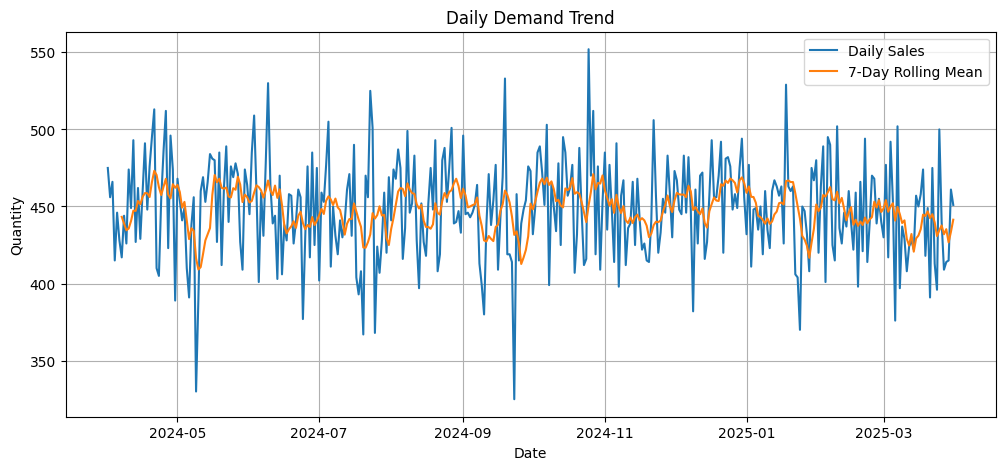

In [59]:
plt.plot(daily_ts.index, daily_ts['total_quantity'], label='Daily Sales')
plt.plot(daily_ts.index, daily_ts['total_quantity'].rolling(7).mean(), label='7-Day Rolling Mean')
plt.title("Daily Demand Trend")
plt.xlabel("Date")
plt.ylabel("Quantity")
plt.legend()
plt.show()

## 6) Weekly Seasonality

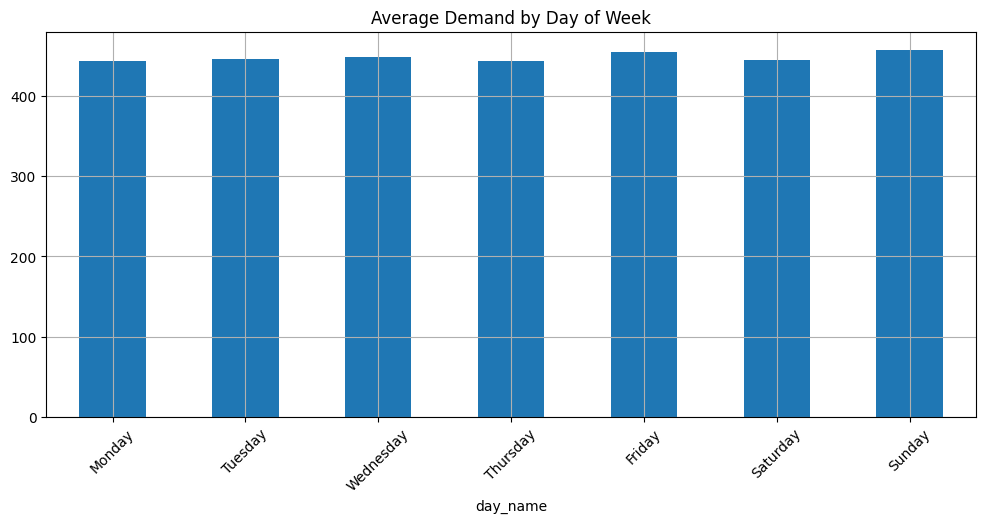

In [60]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

weekly_avg = (
    daily_ts.assign(day_name=daily_ts.index.day_name())
    .groupby('day_name')['total_quantity']
    .mean()
    .reindex(weekday_order)
)

weekly_avg.plot(kind='bar')
plt.title("Average Demand by Day of Week")
plt.xticks(rotation=45)
plt.show()

## 7) Monthly Seasonality

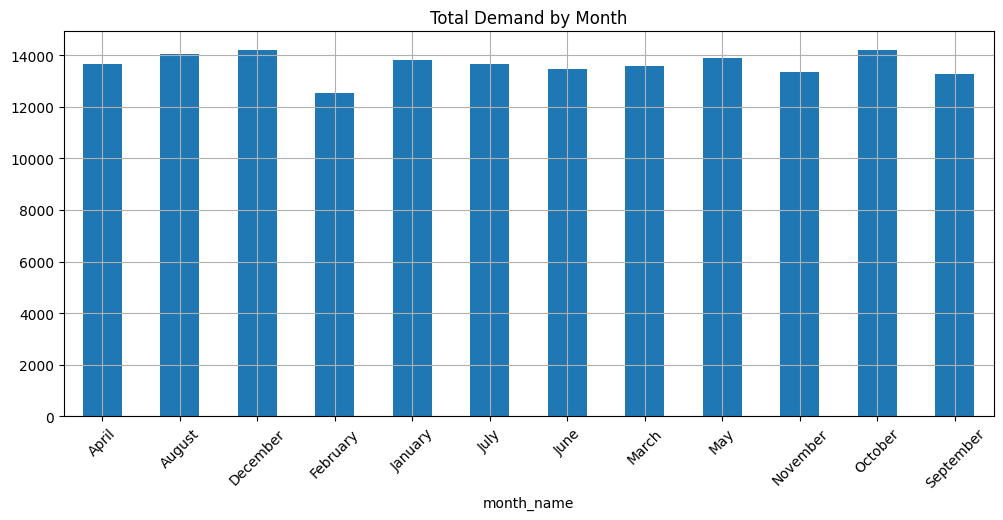

In [61]:
monthly_total = (
    daily_ts.assign(month_name=daily_ts.index.month_name())
    .groupby('month_name')['total_quantity']
    .sum()
)

monthly_total.plot(kind='bar')
plt.title("Total Demand by Month")
plt.xticks(rotation=45)
plt.show()

## 8) Hourly Demand Pattern

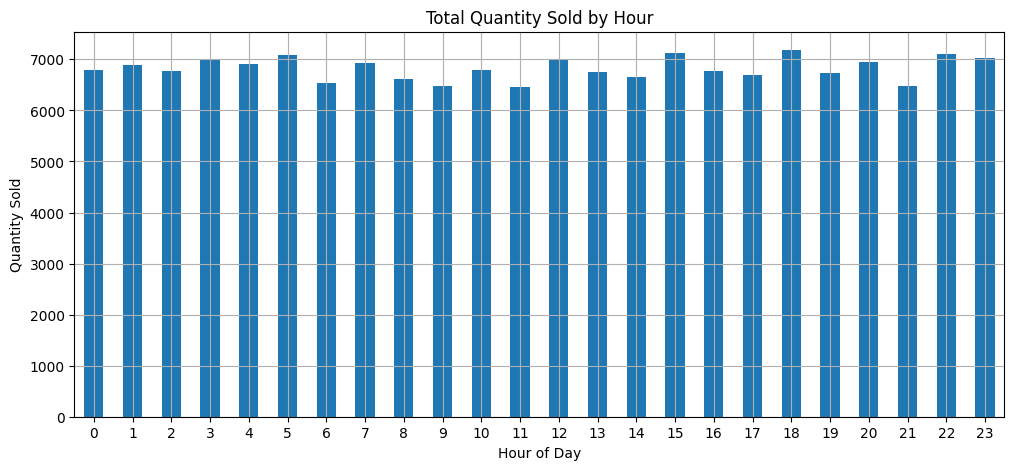

In [62]:
hourly_quantity = df.groupby("hour")["quantity"].sum().sort_index()

fig, ax = plt.subplots()
hourly_quantity.plot(kind="bar", ax=ax)
ax.set_title("Total Quantity Sold by Hour")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Quantity Sold")
plt.xticks(rotation=0)
plt.show()


## 9) Top Selling Items

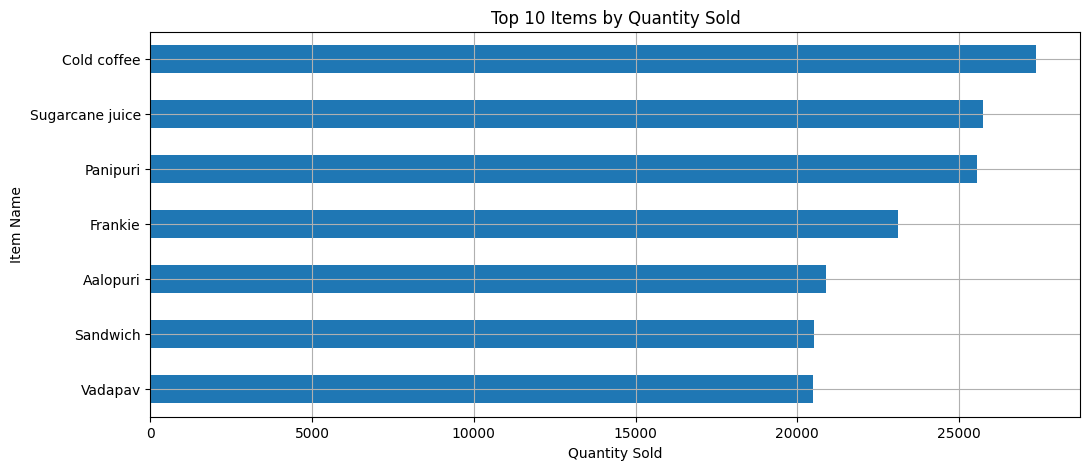

In [63]:
top_items = df.groupby("item_name")["quantity"].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots()
top_items.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top 10 Items by Quantity Sold")
ax.set_xlabel("Quantity Sold")
ax.set_ylabel("Item Name")
plt.show()


## 10) Time-Series Decomposition

- We assume weekly seasonality (period = 7 days).

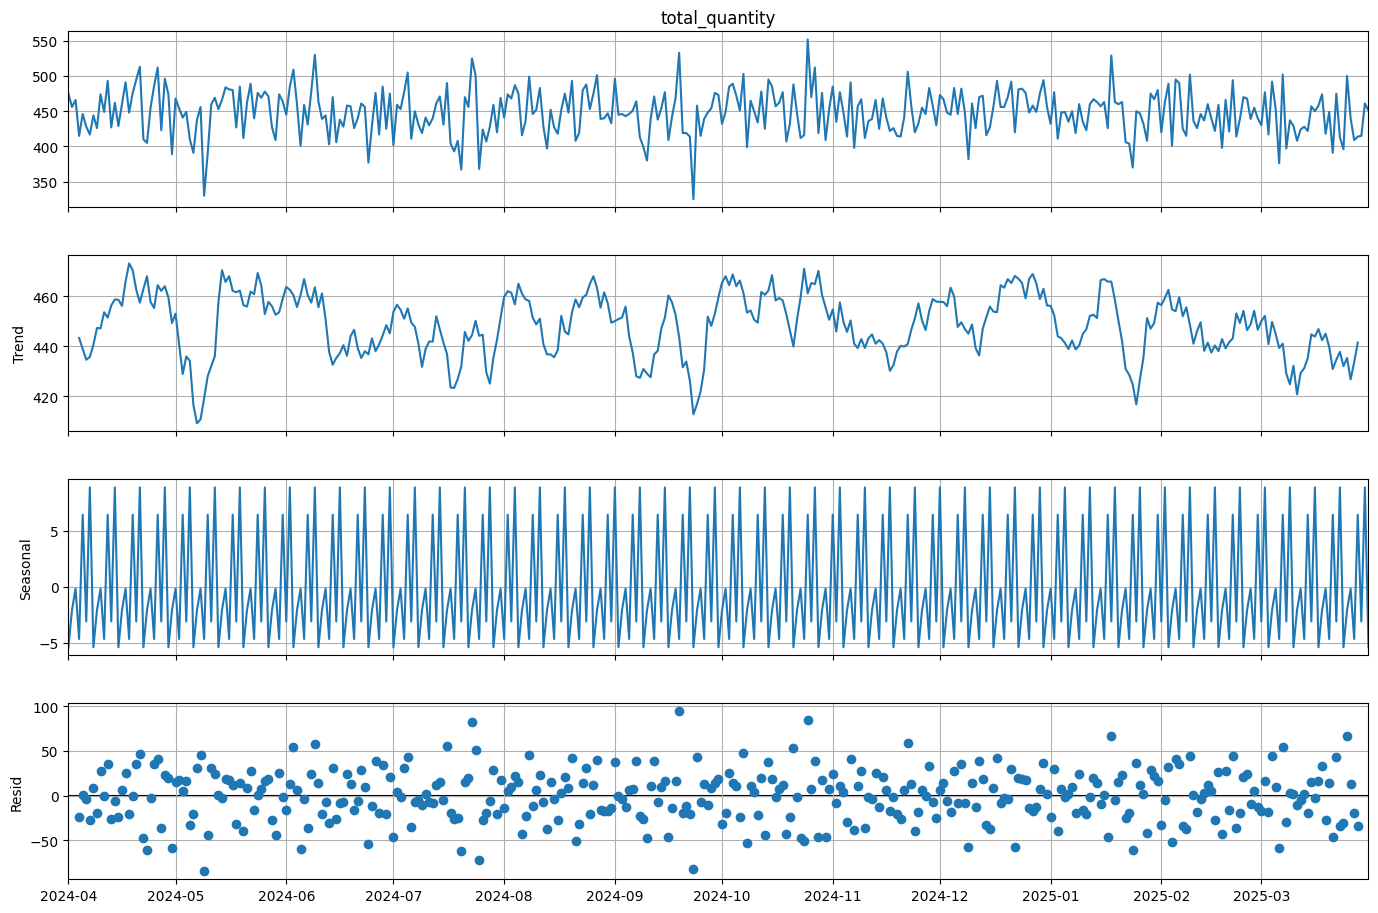

In [64]:
ts_for_decomposition = daily_ts["total_quantity"].asfreq("D").fillna(0)

decomp = seasonal_decompose(ts_for_decomposition, model="additive", period=7)

fig = decomp.plot()
fig.set_size_inches(14, 10)
plt.show()


## 11) Autocorrelation Analysis

- ACF shows correlation with past values
- PACF shows direct impact of past lags

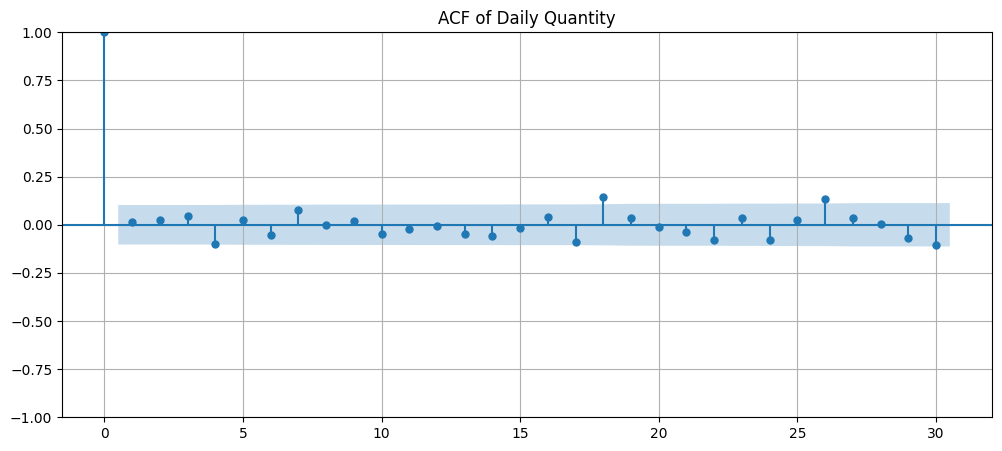

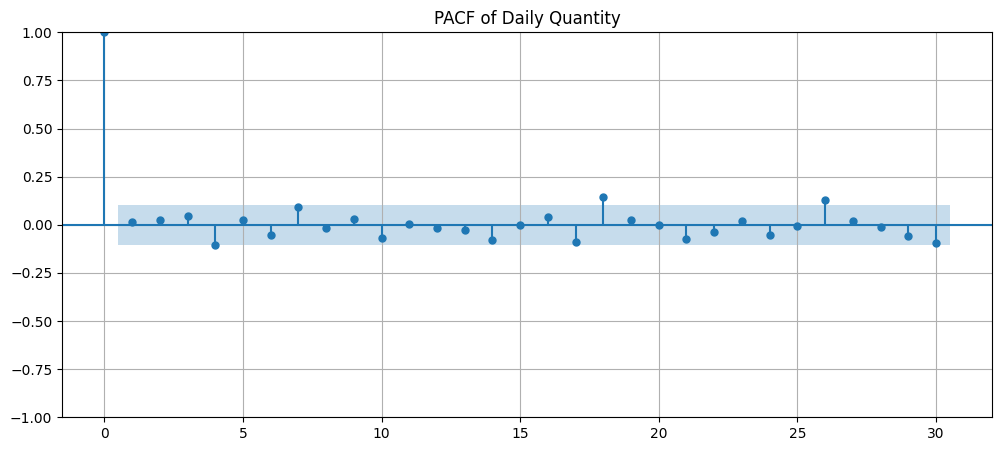

In [65]:
fig, ax = plt.subplots()
plot_acf(ts_for_decomposition, lags=30, ax=ax)
ax.set_title("ACF of Daily Quantity")
plt.show()

fig, ax = plt.subplots()
plot_pacf(ts_for_decomposition, lags=30, ax=ax, method="ywm")
ax.set_title("PACF of Daily Quantity")
plt.show()


## Stationarity Test (ADF Test)

- Null Hypothesis: Data is non-stationary
- If p-value < 0.05 → stationary

In [67]:
from statsmodels.tsa.stattools import adfuller

ts = daily_ts["total_quantity"]

result = adfuller(ts)

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")

for key, value in result[4].items():
    print(f"   {key}: {value}")

if result[1] < 0.05:
    print("✅ Time series is stationary")
else:
    print("❌ Time series is NOT stationary")

ADF Statistic: -18.73254940114125
p-value: 2.030560678885181e-30
Critical Values:
   1%: -3.4484434475193777
   5%: -2.869513170510808
   10%: -2.571017574266393
✅ Time series is stationary


## 12) Outlier View

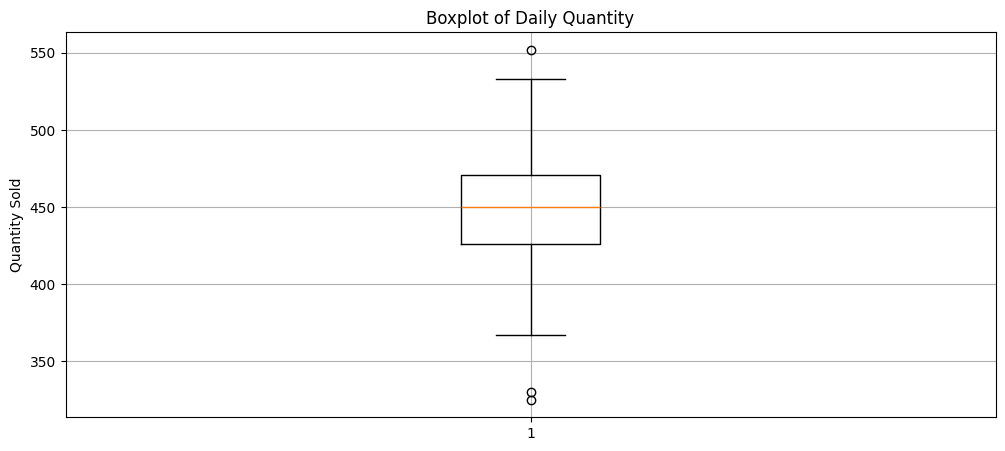

In [68]:
fig, ax = plt.subplots()
ax.boxplot(daily_ts["total_quantity"], vert=True)
ax.set_title("Boxplot of Daily Quantity")
ax.set_ylabel("Quantity Sold")
plt.show()


In [69]:
import pandas as pd

# Load dataset
df = pd.read_csv('../data/raw/balaji_fast_food_sales_dataset.csv')

# FIX: specify dayfirst=True
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

# Create daily demand dataset
daily_demand = df.groupby('date')['quantity'].sum().reset_index()

# Sort
daily_demand = daily_demand.sort_values('date')

# Save
daily_demand.to_csv('../data/processed/daily_demand.csv', index=False)

print("✅ daily_demand.csv saved successfully!")

✅ daily_demand.csv saved successfully!


## 13) Week 1 Summary Insights

In [70]:
print("Week 1 summary:")
print(f"- Continuous daily timeline created with {len(daily_ts)} days.")
print(f"- Empty/missing days filled with zero: {int(daily_ts['is_missing_day'].sum())}.")
print(f"- Highest average demand day: {weekly_avg.idxmax()} ({weekly_avg.max():.2f}).")
print(f"- Highest total month: {monthly_total.idxmax()} ({monthly_total.max():.2f}).")
print(f"- Peak hour: {int(hourly_quantity.idxmax())}:00 ({hourly_quantity.max():.0f}).")
print("- Top 5 items by quantity:")
display(top_items.head())

Week 1 summary:
- Continuous daily timeline created with 365 days.
- Empty/missing days filled with zero: 0.
- Highest average demand day: Sunday (457.38).
- Highest total month: December (14209.00).
- Peak hour: 18:00 (7182).
- Top 5 items by quantity:


item_name
Cold coffee        27383
Sugarcane juice    25726
Panipuri           25562
Frankie            23107
Aalopuri           20898
Name: quantity, dtype: int64

### Final Week 1 Deliverables Covered
- Data ingestion
- Date/time cleaning
- Continuous daily time series
- Overall trend
- Weekly and monthly seasonality
- Hourly pattern
- Top item demand
- Decomposition
- Autocorrelation
- Stationarity Test (ADF Test)
- Outlier review
